In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [134]:
# read in dataframe
df = pd.read_csv("final_data.csv", index_col=0)

# connect to sqlite server 
conn = sqlite3.connect("final_data.db")
cursor = conn.cursor()

In [6]:
df.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'change', 'diabetesMed', 'readmitted',
       'num_hospitalizations', 'avg_procedure', 'total_visits',
       'num_med_changes', 'num_med_increase'],
      dtype='str')

In [5]:
%pip install seaborn
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# distribution of patient demographics

# sql query to find distribution across race
cursor.execute("SELECT race, COUNT(*) as count FROM admissions GROUP BY race ORDER BY count DESC")
results = cursor.fetchall()
for result in results:
    print(result)

('Caucasian', 63154)
('AfricanAmerican', 16800)
('Hispanic', 1488)
('Other', 1267)
('Asian', 545)


In [11]:
# save results
race = []
race_count = []
for result in results:
    race.append(result[0])
    race_count.append(result[1])

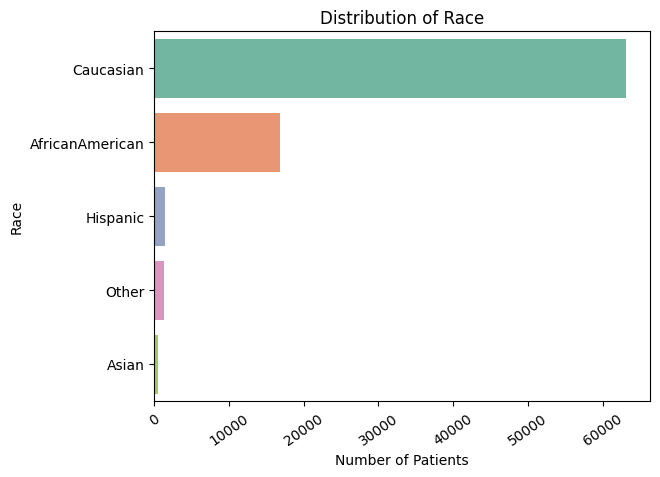

In [33]:
# plot distribution of race
sns.barplot(x=race_count, y=race, hue=race, palette="Set2", legend=False)
plt.ylabel('Race')
plt.xlabel('Number of Patients')
plt.title('Distribution of Race')
plt.xticks(rotation=35)
plt.show()

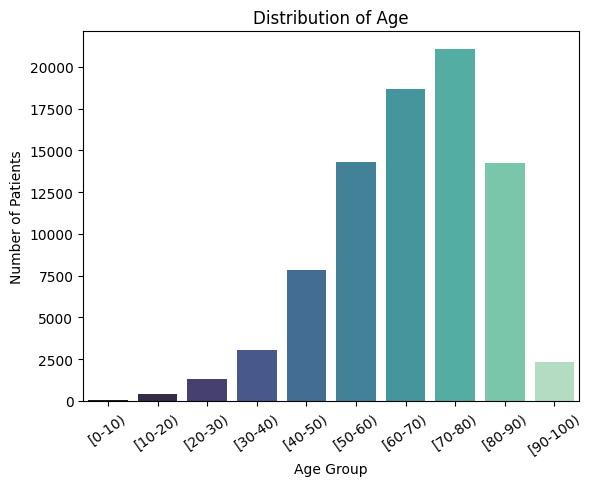

In [120]:
# age distribution

# sql query to find distribution across age
cursor.execute("SELECT age, COUNT(*) as count FROM admissions GROUP BY age ORDER BY age")
results = cursor.fetchall()

ages = []
age_count = []
for result in results:
    ages.append(result[0])
    age_count.append(result[1])

# plot distribution of ages
sns.barplot(y=age_count, x=ages, hue=ages, palette="mako", legend=False)
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.title('Distribution of Age')
plt.xticks(rotation=35)
plt.show()

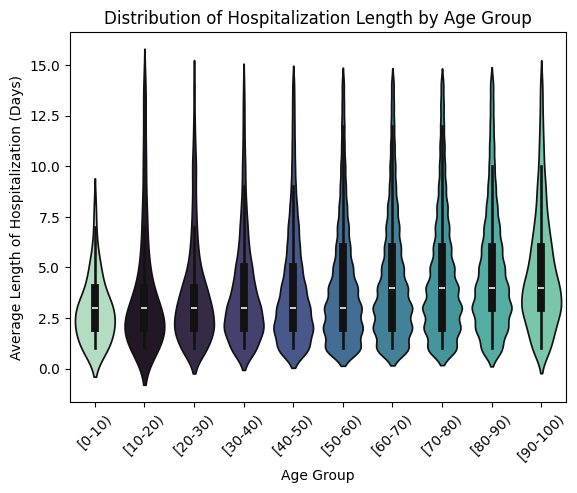

In [132]:
# avg length of stay by age category 
sns.violinplot(data=df, x='age', y='time_in_hospital', order=ages, palette='mako', hue='age', legend=False)
plt.xticks(rotation=45)
plt.title('Distribution of Hospitalization Length by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Length of Hospitalization (Days)')
plt.show()

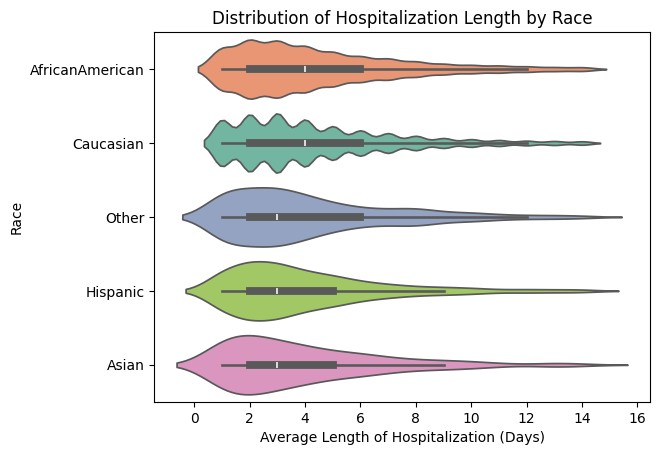

In [ ]:
# avg length of stay by race

# order by highest to lowest
order = df.groupby('race')['time_in_hospital'].mean().sort_values(ascending=False).index

# plot hospitalization across race
sns.violinplot(data=df, y='race', x='time_in_hospital', order=order, palette='Set2', hue='race', legend=False)
plt.title('Distribution of Hospitalization Length by Race')
plt.ylabel('Race')
plt.xlabel('Average Length of Hospitalization (Days)')
plt.show()

Text(0.5, 1.0, 'Readmission Within 30 Days')

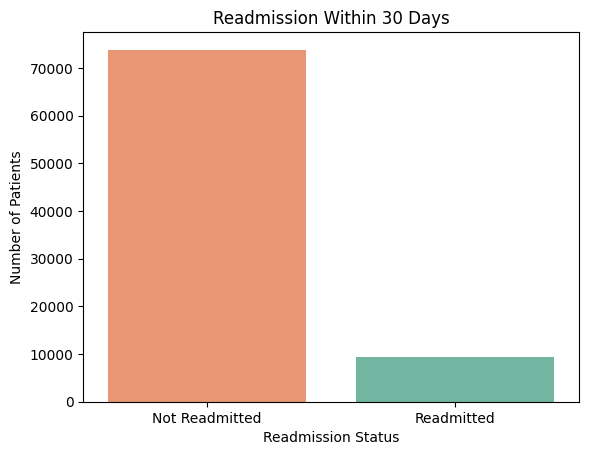

In [131]:
# readmitted vs not readmitted

# sql query to find number of readmitted and nonreadmitted patients within 30 days
cursor.execute("SELECT COUNT(readmitted) as readmission_prop FROM admissions GROUP BY readmitted")
results = cursor.fetchall()

# prepare data for graph
readmission = ['Not Readmitted', 'Readmitted']
readmission_proportions = [x[0] for x in results]

# plot readmitted vs not readmitted
sns.barplot(x=readmission, y=readmission_proportions, hue=readmission_proportions, palette='Set2', legend=False)
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.title('Readmission Within 30 Days')

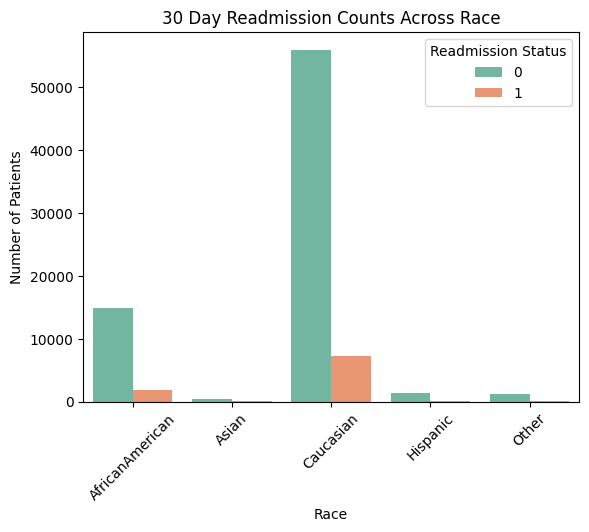

In [123]:
# readmission rate across race groups

# sql query to find readmission counts per race group
cursor.execute("SELECT race, readmitted, COUNT(readmitted) as readmission FROM admissions GROUP BY race, readmitted")
results =  cursor.fetchall()


# save results
race_readmission = []
readmission_status = []
race_readmission_count = []
for result in results:
    race_readmission.append(result[0])
    readmission_status.append(result[1])
    race_readmission_count.append(result[2])

# plot readmission across race
sns.barplot(x=race_readmission, y=race_readmission_count, hue=readmission_status, palette='Set2')
plt.title('30 Day Readmission Counts Across Race')
plt.xlabel('Race')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Readmission Status', loc='upper right')
plt.show()

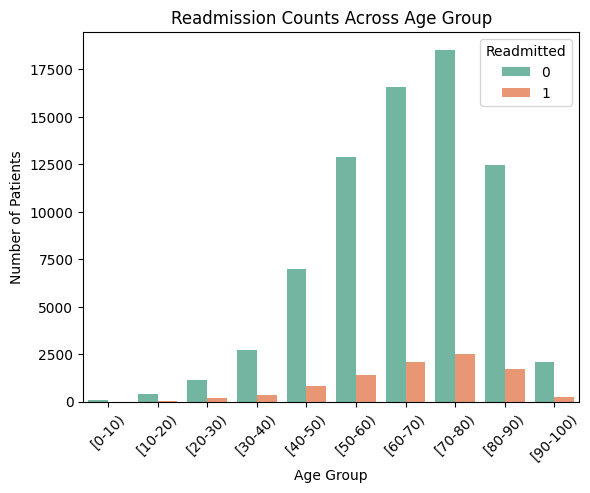

In [124]:
# readmission rate across age groups

# sql query to find readmission counts per age group
cursor.execute("SELECT age, readmitted, COUNT(readmitted) as readmission FROM admissions GROUP BY age, readmitted")
results =  cursor.fetchall()


# save results
age_readmission = []
readmission_status = []
age_readmission_count = []
for result in results:
    age_readmission.append(result[0])
    readmission_status.append(result[1])
    age_readmission_count.append(result[2])

# plot readmission across age groups
sns.barplot(x=age_readmission, y=age_readmission_count, hue=readmission_status, order=ages, palette='Set2')
plt.title('Readmission Counts Across Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Readmitted', loc='upper right')
plt.show()

In [ ]:
# import icd code information 
icd_code_df = pd.read_csv("icd_code.csv", index_col=0)
icd_code_df.columns

Index(['code', 'description', 'primary_category', 'subcategory'], dtype='str')

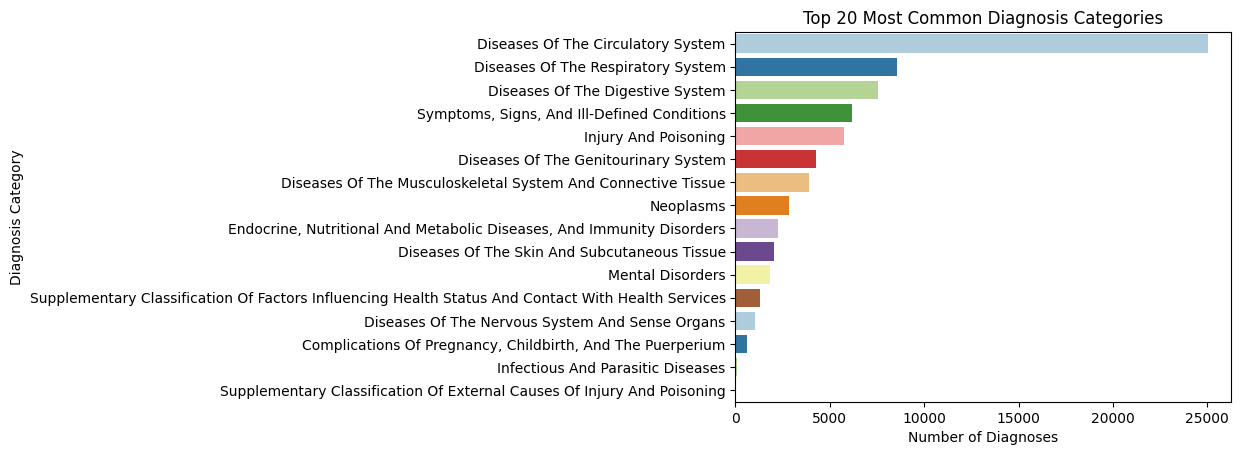

In [125]:
# top 20 diagnosis categories

# join admissions and icd code tables to find top 20 diagnosis categories
cursor.execute("SELECT icd.primary_category, COUNT(a.diag_1) as code_count FROM admissions as a JOIN icd_codes as icd ON icd.code = a.diag_1 GROUP BY icd.primary_category ORDER BY code_count DESC LIMIT 20")
results = cursor.fetchall()

diagnosis_categories = []
code_count = []

# save results
for result in results:
    diagnosis_categories.append(result[0])
    code_count.append(result[1])

# plot top 20 most common diagnosis categories
sns.barplot(x=code_count, y=diagnosis_categories, hue=diagnosis_categories, palette='Paired', legend=False)
plt.title('Top 20 Most Common Diagnosis Categories')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Diagnosis Category')
plt.show()

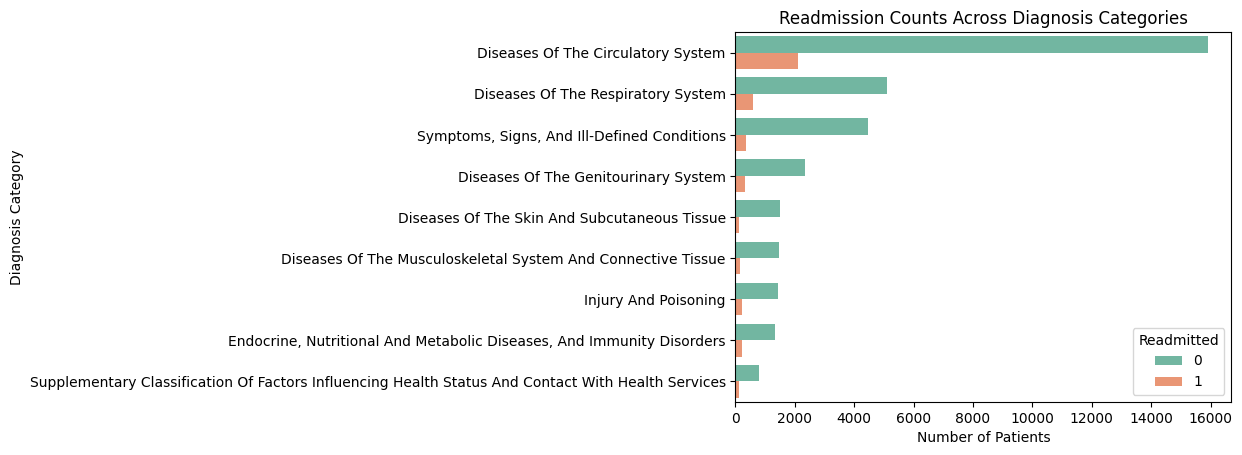

In [130]:
# 30 day readmission across common diagnosis categories

cursor.execute("SELECT icd.primary_category, a.readmitted, COUNT(*) AS count FROM admissions AS a JOIN icd_codes AS icd ON a.diag_1 = icd.code WHERE a.diag_1 IN (SELECT diag_1 FROM admissions GROUP BY diag_1 ORDER BY COUNT(*) DESC LIMIT 20) GROUP BY icd.primary_category, a.readmitted ORDER BY count DESC")
results = cursor.fetchall()

# save results
diagnosis_category_readmission = []
readmission_status = []
diagnosis_category_readmission_count = []
for result in results:
    diagnosis_category_readmission.append(result[0])
    readmission_status.append(result[1])
    diagnosis_category_readmission_count.append(result[2])

# plot readmission across diagnoses
sns.barplot(y=diagnosis_category_readmission, x=diagnosis_category_readmission_count, hue=readmission_status, palette='Set2')
plt.title('Readmission Counts Across Diagnosis Categories')
plt.ylabel('Diagnosis Category')
plt.xlabel('Number of Patients')
plt.legend(title='Readmitted', loc='lower right')
plt.show()

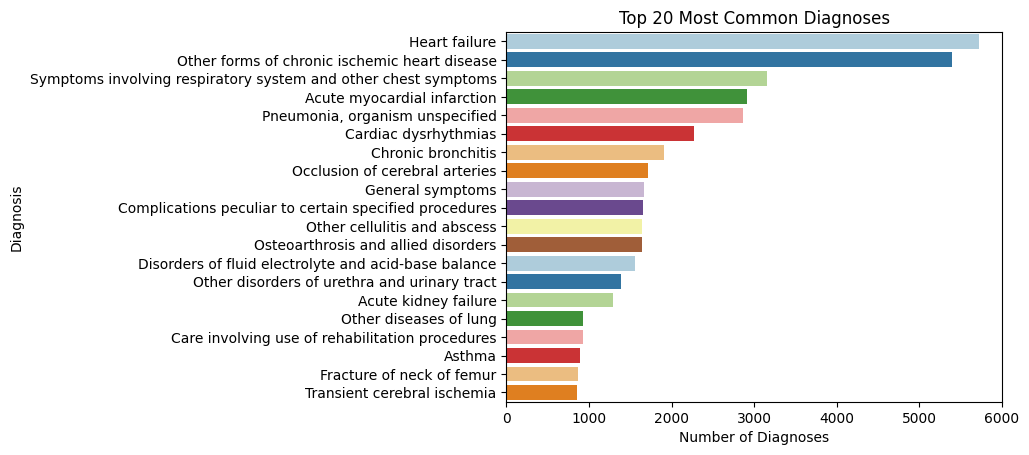

In [126]:
# Top 20 Diagnoses 

# join admissions and icd code tables to find top 20 diagnoses
cursor.execute("SELECT icd.description, COUNT(a.diag_1) as code_count FROM admissions as a JOIN icd_codes as icd ON icd.code = a.diag_1 GROUP BY icd.description ORDER BY code_count DESC LIMIT 20")
results = cursor.fetchall()

diagnosis_desc = []
diagnosis_count = []

# save results
for result in results:
    diagnosis_desc.append(result[0])
    diagnosis_count.append(result[1])

# plot top 20 most common diagnoses
sns.barplot(x=diagnosis_count, y=diagnosis_desc, hue=diagnosis_desc, palette='Paired', legend=False)
plt.title('Top 20 Most Common Diagnoses')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Diagnosis')
plt.show()

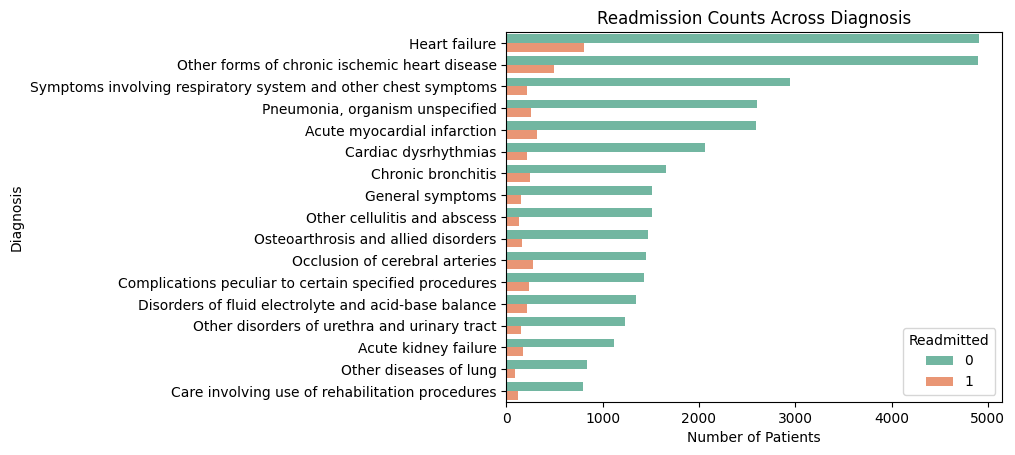

In [128]:
# 30 day readmission across common diagnoses

cursor.execute("SELECT icd.description, a.readmitted, COUNT(*) AS count FROM admissions AS a JOIN icd_codes AS icd ON a.diag_1 = icd.code WHERE a.diag_1 IN (SELECT diag_1 FROM admissions GROUP BY diag_1 ORDER BY COUNT(*) DESC LIMIT 20) GROUP BY icd.description, a.readmitted ORDER BY count DESC")
results = cursor.fetchall()

# save results
diagnosis_readmission = []
readmission_status = []
diagnosis_readmission_count = []
for result in results:
    diagnosis_readmission.append(result[0])
    readmission_status.append(result[1])
    diagnosis_readmission_count.append(result[2])

# plot readmission across diagnoses
sns.barplot(y=diagnosis_readmission, x=diagnosis_readmission_count, hue=readmission_status, palette='Set2')
plt.title('Readmission Counts Across Diagnosis')
plt.ylabel('Diagnosis')
plt.xlabel('Number of Patients')
plt.legend(title='Readmitted', loc='lower right')
plt.show()

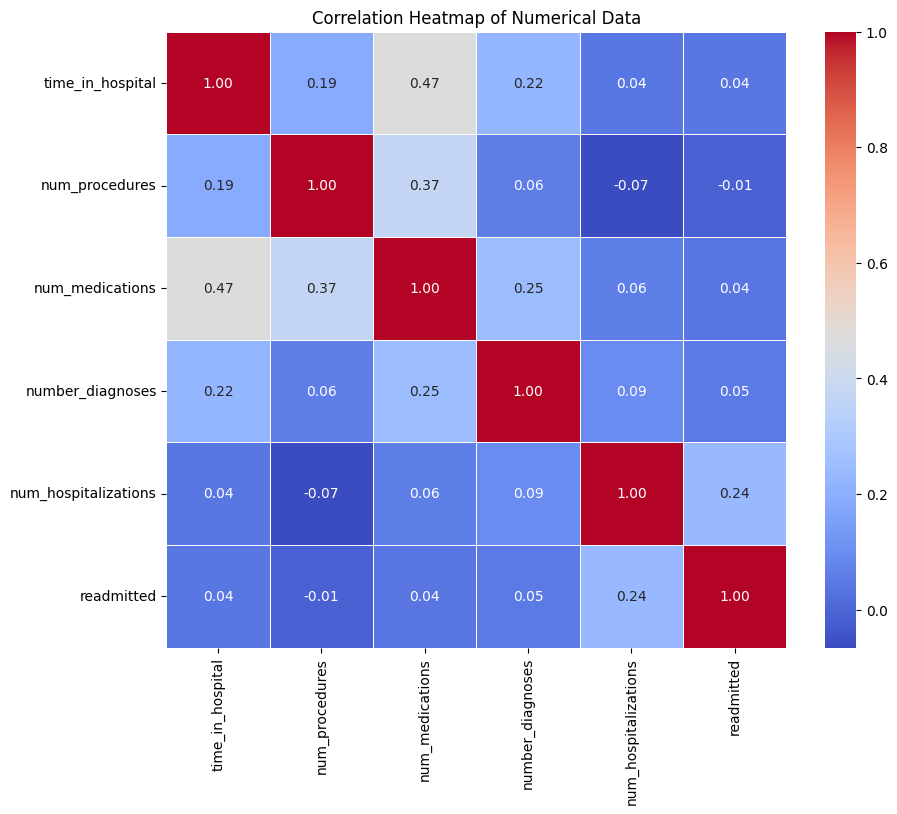

In [135]:
# heatmap of correlation between numeric columns

# save numeric columns
numeric_col = df[['time_in_hospital', 'num_procedures', 'num_medications', 'number_diagnoses', 'num_hospitalizations', 'readmitted']]

# calculate correlation matrix
corr_matrix = numeric_col.corr()

#plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Data')
plt.show()

In [133]:
conn.close()